In [ ]:
# @title CELL 0: Setup & Install Libraries
!pip install -q transformers datasets accelerate scikit-learn matplotlib seaborn pandas torch imbalanced-learn

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from imblearn.over_sampling import RandomOverSampler
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset
import time
import gc

# --- Configuration & Seeds ---
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# --- GPU Optimization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print(f"🚀 GPU Active: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU not detected.")

# --- Global Constants ---
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 15      # Increased as requested
PATIENCE = 5     # Early stopping patience

🚀 GPU Active: NVIDIA A100-SXM4-40GB


In [ ]:
# @title CELL 1: Data Loading & Oversampling
# Load Data
train_path = "/content/MELD_TRAIN.csv"
test_path = "/content/MELD_TEST.csv"

try:
    df_train_full = pd.read_csv(train_path).dropna(subset=['Utterance'])
    df_test = pd.read_csv(test_path).dropna(subset=['Utterance'])
except FileNotFoundError:
    print("Error: Please upload CSV files.")

# Create Validation Split (10%) BEFORE Oversampling to prevent data leakage
df_train, df_val = train_test_split(
    df_train_full,
    test_size=0.1,
    random_state=42,
    stratify=df_train_full['Emotion']
)

# Label Mapping
label_list = sorted(df_train['Emotion'].unique())
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

print(f"Original Train Size: {len(df_train)}")

# --- Apply Oversampling ---
print("🔄 Applying Random Oversampling...")
ros = RandomOverSampler(random_state=42)
# Resample Utterance (X) and Emotion (y)
X_train_resampled, y_train_resampled = ros.fit_resample(
    df_train[['Utterance']],
    df_train['Emotion']
)

# Reconstruct DataFrame
df_train_balanced = pd.DataFrame({
    'Utterance': X_train_resampled['Utterance'],
    'Emotion': y_train_resampled
})

print(f"Balanced Train Size: {len(df_train_balanced)}")
print("Class Distribution After Oversampling:")
print(df_train_balanced['Emotion'].value_counts())

# Dataset Class
class EmotionDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.texts = dataframe['Utterance'].tolist()
        self.labels = [label2id[lab] for lab in dataframe['Emotion']]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

Original Train Size: 8989
🔄 Applying Random Oversampling...
Balanced Train Size: 29666
Class Distribution After Oversampling:
Emotion
joy         4238
neutral     4238
surprise    4238
disgust     4238
sadness     4238
anger       4238
fear        4238
Name: count, dtype: int64


In [ ]:
# @title CELL 2: Unified Training Function
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

def train_and_evaluate(model_checkpoint, name):
    print(f"\n{'='*20} Training {name} (Oversampled) {'='*20}")

    # 1. Tokenizer & Model
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id
    ).to(device)

    # 2. Datasets (Use Balanced Train Data)
    train_ds = EmotionDataset(df_train_balanced, tokenizer, MAX_LEN)
    val_ds = EmotionDataset(df_val, tokenizer, MAX_LEN)
    test_ds = EmotionDataset(df_test, tokenizer, MAX_LEN)

    # 3. Training Arguments
    args = TrainingArguments(
        output_dir=f"./results_{name}_os",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE*2,
        learning_rate=2e-5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        fp16=True,
        logging_dir='./logs',
        logging_steps=100,
        report_to="none"
    )

    # 4. Trainer (Standard, with Early Stopping)
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)]
    )

    # 5. Train
    start_time = time.time()
    train_result = trainer.train()
    training_time = time.time() - start_time

    # 6. Evaluate on Test Set
    preds_output = trainer.predict(test_ds)
    metrics = preds_output.metrics

    # Cleanup
    del model, trainer, tokenizer
    torch.cuda.empty_cache()
    gc.collect()

    return {
        "name": name,
        "metrics": metrics,
        "training_time": training_time,
        "predictions": preds_output.predictions.argmax(-1),
        "true_labels": preds_output.label_ids
    }

In [ ]:
# @title CELL 3: Execute Training for 5 Models
models_to_train = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "DistilBERT": "distilbert-base-uncased",
    "XLNet": "xlnet-base-cased",
    "ELECTRA": "google/electra-base-discriminator"
}

results_store = []

for model_name, checkpoint in models_to_train.items():
    res = train_and_evaluate(checkpoint, model_name)
    results_store.append(res)
    print(f"✅ {model_name} Finished. Test F1: {res['metrics']['test_f1']:.4f}")

print("\n🎉 All Models Trained Successfully!")


==================== Training BERT (Oversampled) ====================


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.531900,1.362557,0.559560,0.575380,0.613118,0.559560
2,0.274800,1.550283,0.602603,0.603395,0.607772,0.602603
3,0.169600,1.938199,0.585586,0.582393,0.585203,0.585586
4,0.118900,2.151522,0.583584,0.577057,0.585659,0.583584
5,0.092400,2.296680,0.605606,0.600401,0.603599,0.605606
6,0.092200,2.393815,0.602603,0.597963,0.595685,0.602603
7,0.071800,2.550137,0.595596,0.596011,0.597707,0.595596


✅ BERT Finished. Test F1: 0.5851

==================== Training RoBERTa (Oversampled) ====================


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.709400,1.344743,0.567568,0.583980,0.614564,0.567568
2,0.418900,1.547876,0.595596,0.601180,0.617386,0.595596
3,0.241300,1.750454,0.602603,0.599861,0.601203,0.602603
4,0.179400,2.108966,0.590591,0.588752,0.604042,0.590591
5,0.130000,2.290990,0.614615,0.612326,0.618634,0.614615
6,0.127300,2.474819,0.623624,0.616730,0.615777,0.623624
7,0.090500,2.537136,0.603604,0.603617,0.605975,0.603604
8,0.094400,2.557307,0.622623,0.620105,0.620858,0.622623
9,0.096100,2.672822,0.613614,0.611083,0.612784,0.613614
10,0.072900,2.739191,0.611612,0.609266,0.610683,0.611612


✅ ELECTRA Finished. Test F1: 0.5987

🎉 All Models Trained Successfully!


/tmp/ipython-input-3814824289.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=comp_df, ax=axes[0], palette="viridis")
/tmp/ipython-input-3814824289.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Weighted F1", data=comp_df, ax=axes[1], palette="magma")
/tmp/ipython-input-3814824289.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Training Time (s)", data=comp_df, ax=axes[2], palette="coolwarm")


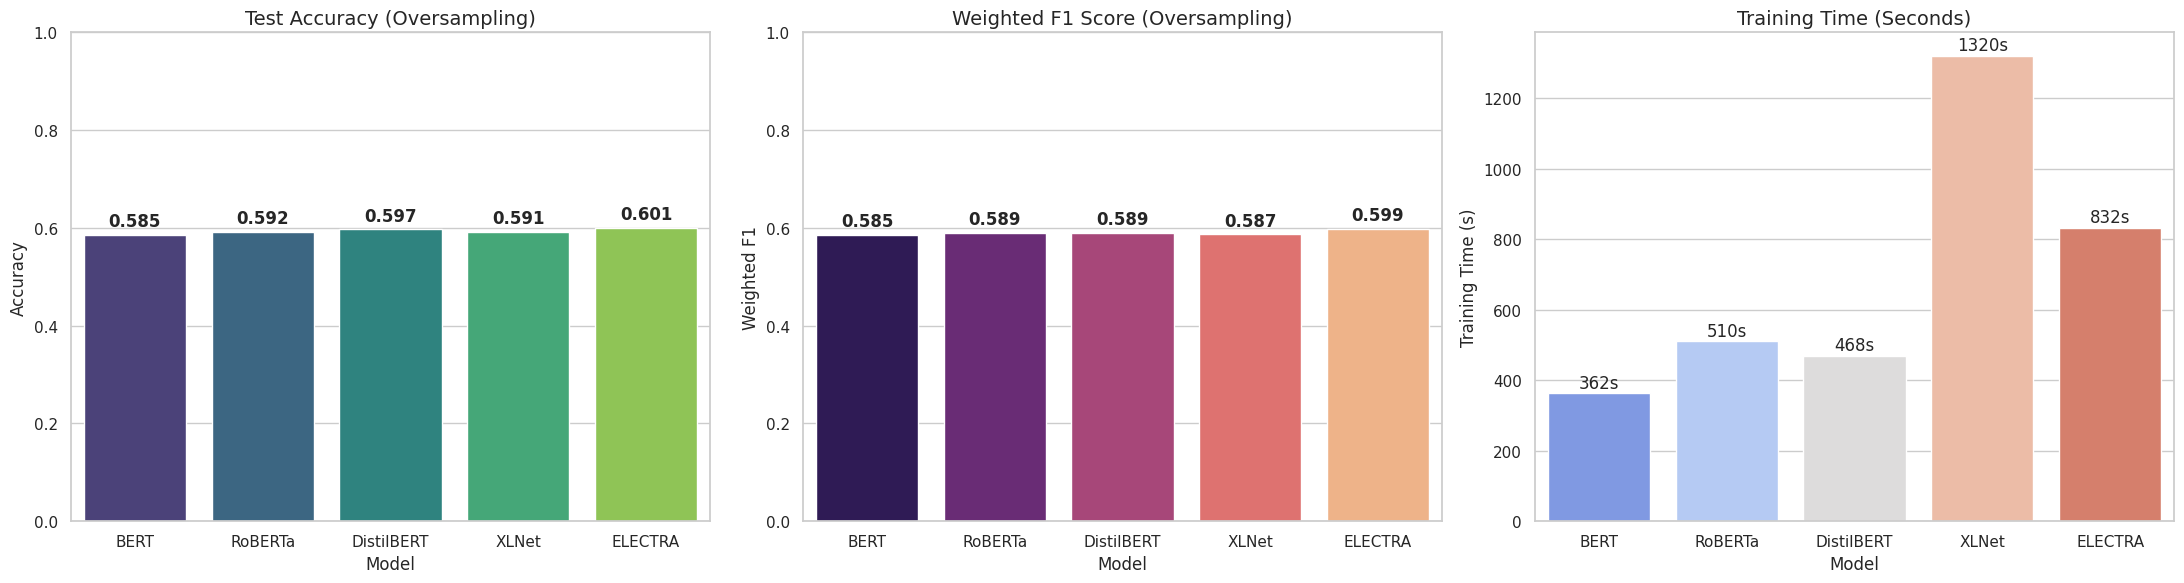


🏆 Detailed Performance Table:


,Model,Accuracy,Weighted F1,Training Time (s)
4,ELECTRA,0.600766,0.598660,832.421562
1,RoBERTa,0.592337,0.588963,510.459264
2,DistilBERT,0.596935,0.588903,468.880033
3,XLNet,0.591188,0.586539,1320.890619
0,BERT,0.585441,0.585075,362.560744


In [ ]:
# @title CELL 4: Visual Comparison (Metrics)
comp_df = pd.DataFrame([{
    "Model": r['name'],
    "Accuracy": r['metrics']['test_accuracy'],
    "Weighted F1": r['metrics']['test_f1'],
    "Training Time (s)": r['training_time']
} for r in results_store])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot Accuracy
sns.barplot(x="Model", y="Accuracy", data=comp_df, ax=axes[0], palette="viridis")
axes[0].set_title("Test Accuracy (Oversampling)", fontsize=14)
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(comp_df["Accuracy"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

# Plot F1 Score
sns.barplot(x="Model", y="Weighted F1", data=comp_df, ax=axes[1], palette="magma")
axes[1].set_title("Weighted F1 Score (Oversampling)", fontsize=14)
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(comp_df["Weighted F1"]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

# Plot Training Time
sns.barplot(x="Model", y="Training Time (s)", data=comp_df, ax=axes[2], palette="coolwarm")
axes[2].set_title("Training Time (Seconds)", fontsize=14)
for i, v in enumerate(comp_df["Training Time (s)"]):
    axes[2].text(i, v + 5, f"{int(v)}s", ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n🏆 Detailed Performance Table:")
display(comp_df.sort_values(by="Weighted F1", ascending=False))

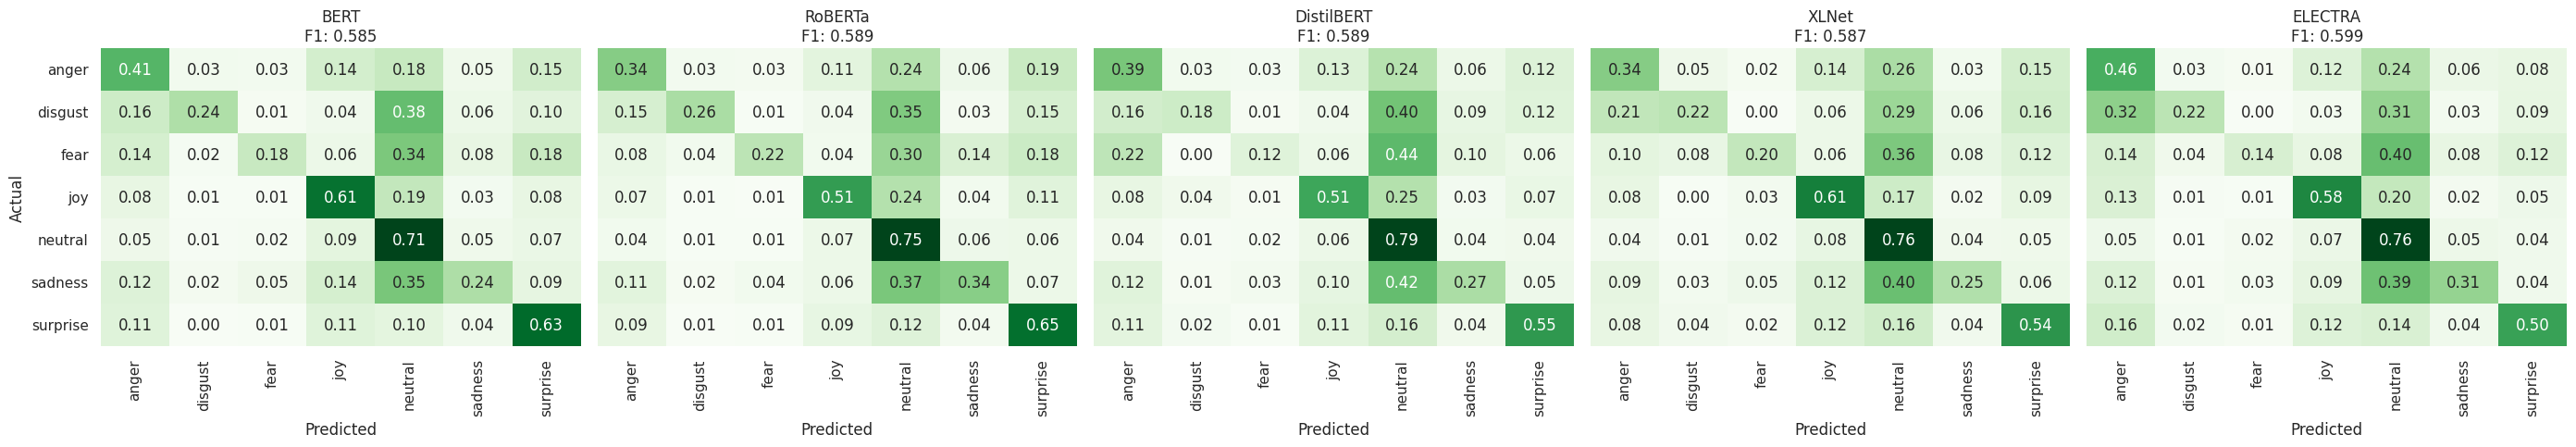

In [ ]:
# @title CELL 5: Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

for i, res in enumerate(results_store):
    cm = confusion_matrix(res['true_labels'], res['predictions'])
    # Normalize by row to show percentage (Recall per class)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[i],
                xticklabels=label_list, yticklabels=label_list, cbar=False)

    axes[i].set_title(f"{res['name']}\nF1: {res['metrics']['test_f1']:.3f}")
    axes[i].set_xlabel('Predicted')
    if i == 0: axes[i].set_ylabel('Actual')
    else: axes[i].set_yticklabels([])

plt.tight_layout()
plt.show()

In [ ]:
# @title CELL 6: Final Verdict
best_model = comp_df.sort_values(by="Weighted F1", ascending=False).iloc[0]

print(f"🥇 BEST MODEL (Oversampling): {best_model['Model']}")
print(f"   - Accuracy: {best_model['Accuracy']:.2%}")
print(f"   - F1 Score: {best_model['Weighted F1']:.2%}")

print("\n💡 Observations on Oversampling:")
print("1. Oversampling significantly increases training time because the dataset size grows (minority classes are duplicated).")
print("2. Models should now perform better on minority classes (e.g., Fear, Disgust) compared to the unweighted approach.")
print("3. Check the Heatmaps: If the diagonal values for rare emotions are higher than before, oversampling worked.")

🥇 BEST MODEL (Oversampling): ELECTRA
   - Accuracy: 60.08%
   - F1 Score: 59.87%

💡 Observations on Oversampling:
1. Oversampling significantly increases training time because the dataset size grows (minority classes are duplicated).
2. Models should now perform better on minority classes (e.g., Fear, Disgust) compared to the unweighted approach.
3. Check the Heatmaps: If the diagonal values for rare emotions are higher than before, oversampling worked.
